# Part e
### Introducing L1 and L2 terms

In [ ]:
from pathlib import Path
import sys


here = Path.cwd()
candidates = [here] + list(here.parents)
for p in candidates:
    if (p / "Code").is_dir():
        sys.path.insert(0, str(p))
        break
else:
    raise RuntimeError("Couldn't find a 'Code' folder in this project.")



import autograd.numpy as np
import matplotlib.pyplot as plt

from Code.ffnn2 import NeuralNetwork as FFNN 
from Code.scheduler import Adam, RMS_prop, Constant, Scheduler
from Code.data import runge_function, make_data
from Code.cost import CostOLS, dCostOLS
from Code.activations import RELU, identity, derivate
from Code.scheduler import Constant, RMS_prop, Adam
from Code.architectures import  build_architectures_exact
from Code.helpers import train_eval_once, optimizers_to_sweep, activation_tests
%matplotlib inline


import pandas as pd
import seaborn as sns 
sns.set_theme(style="white", font_scale=1.3)
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["figure.dpi"] = 200
plt.rcParams.update({
    "savefig.dpi": 200,
    "savefig.bbox": "tight"
})



In [2]:
#Initialize data

(seed_fixed,
 rng_fixed,
 X_fixed_test,
 y_fixed_test,
 N,
 rng,
 x,
 noise,
 y,
 X_train,
 X_val,
 y_train,
 y_val,
 scaler,
 X_train_scaled,
 X_val_scaled,
 X_fixed_test_scaled) = make_data(seed_fixed=42, N=200, noise_std=0.1, test_N=2000)



In [3]:
eta_vals = np.logspace(-4, -1, 4) # Sweep 4 values
lam_vals = [1e-4, 1e-3, 1e-2, 0] #l2
l1_vals = [1e-4, 1e-3, 1e-2, 0 ] #l1
epochs_sweep = 10 #less epochs because of the large number of runs

input_nodes = X_train_scaled.shape[1] 

lam = 0.0
batches = 32


import itertools


In [ ]:
depths = [0, 1, 2]          
widths = [50, 100, 200] 

architectures_to_sweep = build_architectures_exact(out_dim=1)


## L2 regularization

In [ ]:

# Optimizers and activations are imported from helpers.py
print("sizes:",
      len(architectures_to_sweep),
      len(optimizers_to_sweep),
      len(activation_tests),
      len(eta_vals),
      len(lam_vals))

# Total combinations
combos = list(itertools.product(
    architectures_to_sweep.items(),
    activation_tests.items(), 
    optimizers_to_sweep.items(),
    eta_vals, lam_vals
))
print("total combos:", len(combos))

import random
random.seed(42)
sample = random.sample(combos, k=min(120, len(combos)))
print("sample size:", len(sample))


#To get an idea of runtime
import math, time
total = len(architectures_to_sweep) * len(activation_tests) * len(optimizers_to_sweep) * len(eta_vals) * len(lam_vals)
print("Total runs:", total)


L2_sweep_results = {}

print("\n\n================ L2 (Ridge) Regularization with Activation Sweep ================")

# Iterate over architectures
for arch_name, layer_sizes in architectures_to_sweep.items():
    print(f"\n---- Architecture: {arch_name} ----")
    act_bucket = {}  # activation -> optimizer -> (len(eta) x len(lam)) grid
    n_hidden_layers = max(0, len(layer_sizes) - 1)

    # Iterate over activations
    for act_name, h_func in activation_tests.items():
        print(f"  >> Activation: {act_name}")

        # Hidden activations + identity output (regression)
        activation_funcs = [h_func]*n_hidden_layers + [identity]
        activation_ders  = [derivate(f) for f in activation_funcs]

        opt_bucket = {}  # optimizer to grid

        # Iterate over optimizers
        for opt_name, (optimizer_class, fixed_params) in optimizers_to_sweep.items():
            print(f"    --- Optimizer {opt_name} ---")

            # Store results for this optimizer across all eta and lambda values
            grid = np.zeros((len(eta_vals), len(lam_vals)))
             
            # Iterate over eta and lambda values    
            for i, eta in enumerate(eta_vals):
                for j, lam in enumerate(lam_vals):
                    # Prepare optimizer kwargs
                    current_kwargs = {'eta': float(eta)}
                    current_kwargs.update(fixed_params)

                    # Fresh network per run
                    nn = FFNN(
                        network_input_size=input_nodes,
                        layer_output_sizes=tuple(layer_sizes),
                        activation_funcs=activation_funcs,
                        activation_ders=activation_ders,
                        cost_fun=CostOLS,
                        cost_der=dCostOLS,
                        seed=42
                    )
                    nn.reset_weights()

                    # Scheduler & batch mode (GD uses full-batch)
                    scheduler_instance = optimizer_class(**current_kwargs)
                    batches_arg = 1 if opt_name == 'GD' else batches

                    # Train with L2 only (L1=0)
                    _scores = nn.fit(
                        X_train_scaled, y_train,
                        scheduler=scheduler_instance,
                        epochs=epochs_sweep,
                        batches=batches_arg,
                        l1=0.0,
                        l2=float(lam)
                    )

                    # Evaluate on fixed test set
                    y_pred_test = nn.predict(X_fixed_test_scaled)
                    final_mse   = CostOLS(y_pred_test.ravel(), y_fixed_test.ravel())

                    grid[i, j] = final_mse
                    print(f"      act={act_name} | opt={opt_name} | eta={eta:.1e}, lam={lam:.1e} -> MSE={final_mse:.6f}")

            opt_bucket[opt_name] = grid 

        act_bucket[act_name] = opt_bucket

    L2_sweep_results[arch_name] = act_bucket


# flatten L2_sweep_results to a DataFrame
rows = []
for arch_name, act_dict in L2_sweep_results.items():
    for act_name, opt_dict in act_dict.items():
        for opt_name, grid in opt_dict.items():
            for i, eta in enumerate(eta_vals):
                for j, lam in enumerate(lam_vals):
                    rows.append({
                        "architecture": arch_name,
                        "activation": act_name,
                        "optimizer": opt_name,
                        "eta": float(eta),
                        "lam": float(lam),
                        "mse": float(grid[i, j]),
                    })
l2_df = pd.DataFrame(rows)




sizes: 6 4 3 4 4
total combos: 1152
sample size: 120
Total runs: 1152


================ L2 (Ridge) Regularization with Activation Sweep ================

---- Architecture: 0_Hidden_Layers ----
  >> Activation: Sigmoid
    --- Optimizer GD ---
      act=Sigmoid | opt=GD | eta=1.0e-04, lam=1.0e-04 -> MSE=0.169448
      act=Sigmoid | opt=GD | eta=1.0e-04, lam=1.0e-03 -> MSE=0.169448
      act=Sigmoid | opt=GD | eta=1.0e-04, lam=1.0e-02 -> MSE=0.169448
      act=Sigmoid | opt=GD | eta=1.0e-04, lam=0.0e+00 -> MSE=0.169448
      act=Sigmoid | opt=GD | eta=1.0e-03, lam=1.0e-04 -> MSE=0.167001
      act=Sigmoid | opt=GD | eta=1.0e-03, lam=1.0e-03 -> MSE=0.167001
      act=Sigmoid | opt=GD | eta=1.0e-03, lam=1.0e-02 -> MSE=0.167001
      act=Sigmoid | opt=GD | eta=1.0e-03, lam=0.0e+00 -> MSE=0.167001
      act=Sigmoid | opt=GD | eta=1.0e-02, lam=1.0e-04 -> MSE=0.146486
      act=Sigmoid | opt=GD | eta=1.0e-02, lam=1.0e-03 -> MSE=0.146486
      act=Sigmoid | opt=GD | eta=1.0e-02, lam=1.0e-02 -

## L1 regularization

In [ ]:
# same as above for L2 


eta_constant = 1e-2 # if fixed

try:
    eta_values = list(eta_constant)   # iterate over several values
except TypeError:
    eta_values = [eta_constant] 


total = len(architectures_to_sweep) * len(optimizers_to_sweep) * len(activation_tests) *len(eta_vals) * len(l1_vals)
print("Total runs:", total)

L1_sweep_results = {}


print("\n\n================  L1 (Lasso) Regularization  ================")
for arch_name, layer_sizes in architectures_to_sweep.items():
    print(f"\n---- Architecture: {arch_name} ----")
    act_bucket = {}  
    n_hidden_layers = max(0, len(layer_sizes) - 1)

    # === Iterate over activation functions ===
    for act_name, h_func in activation_tests.items():
        print(f"  >> Activation: {act_name}")
        activation_funcs = [h_func]*n_hidden_layers + [identity]
        activation_ders  = [derivate(f) for f in activation_funcs]

        opt_bucket = {}  # optimizer -> grid

        # === Iterate over optimizers ===
        for opt_name, (optimizer_class, fixed_params) in optimizers_to_sweep.items():
            print(f"    --- Optimizer {opt_name} ---")

            # Grid over (eta, L1)
            grid = np.zeros((len(eta_values), len(l1_vals)))
            for i, eta in enumerate(eta_values):
                for j, l1 in enumerate(l1_vals):
                    current_kwargs = {'eta': float(eta)}
                    current_kwargs.update(fixed_params)

                    # Fresh network per run
                    nn = FFNN(
                        network_input_size=input_nodes,
                        layer_output_sizes=tuple(layer_sizes),
                        activation_funcs=activation_funcs,
                        activation_ders=activation_ders,
                        cost_fun=CostOLS, cost_der=dCostOLS,
                        seed=42
                    )
                    nn.reset_weights()

                    scheduler_instance = optimizer_class(**current_kwargs)
                    batches_arg = 1 if opt_name == 'GD' else batches

                    # Train with L1 only (L2=0)
                    _scores = nn.fit(
                        X_train_scaled, y_train,
                        scheduler=scheduler_instance,
                        epochs=epochs_sweep, batches=batches_arg,
                        l1=float(l1), l2=0.0
                    )

                    y_pred_test = nn.predict(X_fixed_test_scaled)
                    final_mse = CostOLS(y_pred_test.ravel(), y_fixed_test.ravel())
                    grid[i, j] = final_mse

                    print(f"      act={act_name} | opt={opt_name} | eta={eta:.1e}, L1={l1:.1e} -> MSE={final_mse:.6f}")

            opt_bucket[opt_name] = grid

        act_bucket[act_name] = opt_bucket

    L1_sweep_results[arch_name] = act_bucket

# Flatten L1_sweep_results to a DataFrame
rows = []
for arch_name, act_dict in L1_sweep_results.items():
    for act_name, opt_dict in act_dict.items():
        for opt_name, grid in opt_dict.items():
            for i, eta in enumerate(eta_values):
                for j, l1 in enumerate(l1_vals):
                    rows.append({
                        "architecture": arch_name,
                        "activation": act_name,
                        "optimizer": opt_name,
                        "eta": float(eta),
                        "l1": float(l1),
                        "mse": float(grid[i, j]),
                    })
l1_df = pd.DataFrame(rows)

Total runs: 1152


================  L1 (Lasso) Regularization  ================

---- Architecture: 0_Hidden_Layers ----
  >> Activation: Sigmoid
    --- Optimizer GD ---
      act=Sigmoid | opt=GD | eta=1.0e-02, L1=1.0e-04 -> MSE=0.146486
      act=Sigmoid | opt=GD | eta=1.0e-02, L1=1.0e-03 -> MSE=0.146485
      act=Sigmoid | opt=GD | eta=1.0e-02, L1=1.0e-02 -> MSE=0.146480
      act=Sigmoid | opt=GD | eta=1.0e-02, L1=0.0e+00 -> MSE=0.146486
    --- Optimizer SGD ---
      act=Sigmoid | opt=SGD | eta=1.0e-02, L1=1.0e-04 -> MSE=0.094824
      act=Sigmoid | opt=SGD | eta=1.0e-02, L1=1.0e-03 -> MSE=0.094804
      act=Sigmoid | opt=SGD | eta=1.0e-02, L1=1.0e-02 -> MSE=0.094634
      act=Sigmoid | opt=SGD | eta=1.0e-02, L1=0.0e+00 -> MSE=0.094826
    --- Optimizer RMS_prop ---
      act=Sigmoid | opt=RMS_prop | eta=1.0e-02, L1=1.0e-04 -> MSE=0.094251
      act=Sigmoid | opt=RMS_prop | eta=1.0e-02, L1=1.0e-03 -> MSE=0.094239
      act=Sigmoid | opt=RMS_prop | eta=1.0e-02, L1=1.0e-02 -> MSE

In [7]:
K = 10  # top 10 runs

# L1
topk_l1 = l1_df.nsmallest(K, "mse").reset_index(drop=True)
best_l1 = l1_df.nsmallest(1, "mse").reset_index(drop=True)

print("\n=== Top-K L1 runs ===")
display(topk_l1)
print("\n=== Absolute best L1 ===")
display(best_l1)

# L2
topk_l2 = l2_df.nsmallest(K, "mse").reset_index(drop=True)
best_l2 = l2_df.nsmallest(1, "mse").reset_index(drop=True)

print("\n=== Top-K L2 runs ===")
display(topk_l2)
print("\n=== Absolute best L2 ===")
display(best_l2)



=== Top-K L1 runs ===


,architecture,activation,optimizer,eta,l1,mse
0,"2_Hidden_Layers (50, 100)",RELU,RMS_prop,0.01,0.0001,0.011134
1,"2_Hidden_Layers (50, 100)",LRELU,RMS_prop,0.01,0.0000,0.011257
2,"2_Hidden_Layers (100, 200)",RELU,RMS_prop,0.01,0.0001,0.011366
3,"2_Hidden_Layers (50, 100)",LRELU,Adam,0.01,0.0000,0.012285
4,"2_Hidden_Layers (50, 100)",RELU,Adam,0.01,0.0000,0.012298
5,"3_Hidden_Layers (50, 100, 200)",LRELU,Adam,0.01,0.0000,0.012322
6,"3_Hidden_Layers (50, 100, 200)",RELU,Adam,0.01,0.0001,0.012428
7,"3_Hidden_Layers (50, 100, 200)",LRELU,Adam,0.01,0.0001,0.012554
8,"2_Hidden_Layers (50, 100)",LRELU,RMS_prop,0.01,0.0001,0.012626
9,"2_Hidden_Layers (50, 100)",RELU,RMS_prop,0.01,0.0000,0.012688



=== Absolute best L1 ===


,architecture,activation,optimizer,eta,l1,mse
0,"2_Hidden_Layers (50, 100)",RELU,RMS_prop,0.01,0.0001,0.011134



=== Top-K L2 runs ===


,architecture,activation,optimizer,eta,lam,mse
0,"3_Hidden_Layers (50, 100, 200)",RELU,Adam,0.010,0.0010,0.010620
1,"3_Hidden_Layers (50, 100, 200)",LRELU,Adam,0.001,0.0001,0.010724
2,"3_Hidden_Layers (50, 100, 200)",RELU,Adam,0.001,0.0000,0.010835
3,"3_Hidden_Layers (50, 100, 200)",RELU,Adam,0.001,0.0001,0.011008
4,"3_Hidden_Layers (50, 100, 200)",LRELU,Adam,0.001,0.0000,0.011042
5,"2_Hidden_Layers (50, 100)",LRELU,RMS_prop,0.010,0.0000,0.011257
6,"3_Hidden_Layers (50, 100, 200)",LRELU,Adam,0.010,0.0010,0.011264
7,"2_Hidden_Layers (50, 100)",LRELU,Adam,0.100,0.0001,0.011802
8,"3_Hidden_Layers (50, 100, 200)",LRELU,RMS_prop,0.001,0.0000,0.011844
9,"3_Hidden_Layers (50, 100, 200)",RELU,RMS_prop,0.001,0.0001,0.011939



=== Absolute best L2 ===


,architecture,activation,optimizer,eta,lam,mse
0,"3_Hidden_Layers (50, 100, 200)",RELU,Adam,0.01,0.001,0.01062


## Retraining and finding the best combo overall

In [ ]:

RETRAIN_EPOCHS = 500 # more epochs for retraining

def retrain_table(df_in, reg_type, reg_value_col, repeats=1,
                  old_mse_col="mse",
                  epochs=500, batches=32):

    required = ["architecture", "activation", "optimizer", "eta",
                reg_value_col, old_mse_col]
    missing = [c for c in required if c not in df_in.columns]
    if missing:
        raise ValueError(f"retrain_table: missing columns in df_in: {missing}")

    rows = []
    input_dim = X_train_scaled.shape[1]

    # Iterate over rows in df_in
    for i, r in df_in.iterrows():
        arch_name = r["architecture"]
        act_name  = r["activation"]
        opt_name  = r["optimizer"]
        eta       = float(r["eta"])
        regv      = float(r[reg_value_col])

        # Original MSE
        raw_old = r[old_mse_col]
        if isinstance(raw_old, (tuple, list, np.ndarray)):
            old = float(raw_old[0])
        else:
            old = float(raw_old)

        # Architecture -> layer sizes
        try:
            layer_sizes = architectures_to_sweep[arch_name]
        except KeyError:
            raise KeyError(
                f"Unknown architecture '{arch_name}' "
                f"(not in architectures_to_sweep)."
            )

        # Decide which regularization parameter to use
        if reg_type == "L1":
            l1, l2 = regv, 0.0
        elif reg_type == "L2":
            l1, l2 = 0.0, regv
        else:
            raise ValueError("reg_type must be 'L1' or 'L2'.")

        # Retrain repeats times and average
        vals = []
        for _ in range(repeats):
            mse = train_eval_once(
                opt_name,
                eta,
                X_train_scaled,
                y_train,
                X_fixed_test_scaled,
                y_fixed_test,
                input_dim,
                layer_sizes,
                act_name,
                epochs=epochs,
                batches=batches,
                l1=l1,
                l2=l2,
                lam=0.0,  
            )
            vals.append(mse)

        new_mse = float(np.mean(vals))
        delta = new_mse - old

        print(
            f"{i+1:02d}. {arch_name} | {act_name} | {opt_name} | "
            f"η={eta:.1e} | {reg_type}={regv:.1e} "
            f"-> old={old:.6f} | new={new_mse:.6f} | Δ={delta:+.6f}"
        )

        rows.append({
            "architecture": arch_name,
            "activation": act_name,
            "optimizer": opt_name,
            "eta": eta,
            "reg_type": reg_type,
            "reg_value": regv,
            old_mse_col: old,
            "new_mse": new_mse,
            "delta": delta,
            "epochs": epochs,
            "repeats": repeats,
        })

    out = (
        pd.DataFrame(rows)
        .sort_values("new_mse", ascending=True)
        .reset_index(drop=True)
    )

    print("\nSorted by new MSE:")
    print(out.head(min(10, len(out))))
    return out




In [ ]:
# Retrain top-K L1 and L2 runs with more epochs

retrained_topk_l1 = retrain_table(
    topk_l1,
    reg_type="L1",
    reg_value_col="l1",
    repeats=1,
    old_mse_col="mse",
    epochs=500,
    batches=32  # or whatever you used
)

retrained_topk_l2 = retrain_table(
    topk_l2,
    reg_type="L2",
    reg_value_col="lam",
    repeats=1,
    old_mse_col="mse",
    epochs=500,
    batches=32
)


01. 2_Hidden_Layers (50, 100) | RELU | RMS_prop | η=1.0e-02 | L1=1.0e-04 -> old=0.011134 | new=0.011118 | Δ=-0.000017
02. 2_Hidden_Layers (50, 100) | LRELU | RMS_prop | η=1.0e-02 | L1=0.0e+00 -> old=0.011257 | new=0.011423 | Δ=+0.000166
03. 2_Hidden_Layers (100, 200) | RELU | RMS_prop | η=1.0e-02 | L1=1.0e-04 -> old=0.011366 | new=0.012433 | Δ=+0.001067
04. 2_Hidden_Layers (50, 100) | LRELU | Adam | η=1.0e-02 | L1=0.0e+00 -> old=0.012285 | new=0.011035 | Δ=-0.001250
05. 2_Hidden_Layers (50, 100) | RELU | Adam | η=1.0e-02 | L1=0.0e+00 -> old=0.012298 | new=0.011208 | Δ=-0.001090
06. 3_Hidden_Layers (50, 100, 200) | LRELU | Adam | η=1.0e-02 | L1=0.0e+00 -> old=0.012322 | new=0.010961 | Δ=-0.001361
07. 3_Hidden_Layers (50, 100, 200) | RELU | Adam | η=1.0e-02 | L1=1.0e-04 -> old=0.012428 | new=0.010895 | Δ=-0.001533
08. 3_Hidden_Layers (50, 100, 200) | LRELU | Adam | η=1.0e-02 | L1=1.0e-04 -> old=0.012554 | new=0.010884 | Δ=-0.001670
09. 2_Hidden_Layers (50, 100) | LRELU | RMS_prop | η=1.0

In [ ]:
# Best after retraining (L1)
best_l1_idx = retrained_topk_l1["new_mse"].idxmin()
best_l1 = retrained_topk_l1.loc[best_l1_idx]

print("\n=== Best L1 after retraining ===")
print(f"{best_l1['architecture']} | {best_l1['activation']} | {best_l1['optimizer']}"
      f" | η={best_l1['eta']:.1e} | L1={best_l1['reg_value']:.1e}"
      f" -> old={best_l1['mse']:.6f} | new={best_l1['new_mse']:.6f}"
      f" | Δ={best_l1['delta']:+.6f}")

# Best after retraining (L2)
best_l2_idx = retrained_topk_l2["new_mse"].idxmin()
best_l2 = retrained_topk_l2.loc[best_l2_idx]

print("\n=== Best L2 after retraining ===")
print(f"{best_l2['architecture']} | {best_l2['activation']} | {best_l2['optimizer']}"
      f" | η={best_l2['eta']:.1e} | L2={best_l2['reg_value']:.1e}"
      f" -> old={best_l2['mse']:.6f} | new={best_l2['new_mse']:.6f}"
      f" | Δ={best_l2['delta']:+.6f}")



=== Best L1 after retraining ===
2_Hidden_Layers (50, 100) | LRELU | RMS_prop | η=1.0e-02 | L1=1.0e-04 -> old=0.012626 | new=0.010515 | Δ=-0.002111

=== Best L2 after retraining ===
3_Hidden_Layers (50, 100, 200) | RELU | RMS_prop | η=1.0e-03 | L2=1.0e-04 -> old=0.011939 | new=0.010386 | Δ=-0.001553


In [ ]:

E_PART_E = 500   
BATCH_PART_E = 32

input_dim = X_train_scaled.shape[1]

# ---------- Best L1 from sweep ----------
best_l1 = l1_df.loc[l1_df["mse"].idxmin()]

best_l1_arch = best_l1["architecture"]
best_l1_act  = best_l1["activation"]
best_l1_opt  = best_l1["optimizer"]
best_l1_eta  = float(best_l1["eta"])
best_l1_val  = float(best_l1["l1"])

l1_layer_sizes = architectures_to_sweep[best_l1_arch]

mse_l1_fresh = train_eval_once(
    best_l1_opt,
    best_l1_eta,
    X_train_scaled,
    y_train,
    X_fixed_test_scaled,
    y_fixed_test,
    input_dim,
    l1_layer_sizes,
    best_l1_act,
    epochs=E_PART_E,
    batches=BATCH_PART_E,
    l1=best_l1_val,
    l2=0.0,
    lam=0.0
)

print("\n=== Part (e): best L1 retrained from scratch ===")
print(f"{best_l1_arch} | {best_l1_act} | {best_l1_opt} | "
      f"η={best_l1_eta:.1e} | L1={best_l1_val:.1e} "
      f"-> MSE_sweep={best_l1['mse']:.6f} | MSE_fresh={mse_l1_fresh:.6f}")


# Best L2 from sweep 
best_l2 = l2_df.loc[l2_df["mse"].idxmin()]

best_l2_arch = best_l2["architecture"]
best_l2_act  = best_l2["activation"]
best_l2_opt  = best_l2["optimizer"]
best_l2_eta  = float(best_l2["eta"])
best_l2_val  = float(best_l2["lam"])

l2_layer_sizes = architectures_to_sweep[best_l2_arch]

# Compute fresh MSE, fresh as in new network with same hyperparameters
mse_l2_fresh = train_eval_once(
    best_l2_opt,
    best_l2_eta,
    X_train_scaled,
    y_train,
    X_fixed_test_scaled,
    y_fixed_test,
    input_dim,
    l2_layer_sizes,
    best_l2_act,
    epochs=E_PART_E,
    batches=BATCH_PART_E,
    l1=0.0,
    l2=best_l2_val,
    lam=0.0
)

print("\n=== Part (e): best L2 retrained from scratch ===")
print(f"{best_l2_arch} | {best_l2_act} | {best_l2_opt} | "
      f"η={best_l2_eta:.1e} | L2={best_l2_val:.1e} "
      f"-> MSE_sweep={best_l2['mse']:.6f} | MSE_fresh={mse_l2_fresh:.6f}")



=== Part (e): best L1 retrained from scratch ===
2_Hidden_Layers (50, 100) | RELU | RMS_prop | η=1.0e-02 | L1=1.0e-04 -> MSE_sweep=0.011134 | MSE_fresh=0.011452

=== Part (e): best L2 retrained from scratch ===
3_Hidden_Layers (50, 100, 200) | RELU | Adam | η=1.0e-02 | L2=1.0e-03 -> MSE_sweep=0.010620 | MSE_fresh=0.011619


In [ ]:
# Now retrain best L1 and L2 networks fully to get predictions for plotting

rho_val = 0.9    
rho2_val = 0.999

x_plot = np.linspace(-1, 1, 500).reshape(-1, 1)
x_plot_scaled = scaler.transform(x_plot)

np.save("x_plot.npy", x_plot_scaled)


layer_sizes_3H = [50, 100, 200, 1] #L2
layer_sizes_2H = [50,100,1] #L1

nn_e_L2 = FFNN(
    network_input_size= 1,
    layer_output_sizes=layer_sizes_3H,
    activation_funcs=[RELU, RELU, RELU, identity],
    activation_ders=[derivate(RELU), derivate(RELU),derivate(RELU), derivate(identity)],
    cost_fun=CostOLS,
    cost_der=dCostOLS,
    seed=42
)

nn_e_L1 = FFNN(
    network_input_size= 1,
    layer_output_sizes=layer_sizes_2H,
    activation_funcs=[RELU, RELU, identity],
    activation_ders=[derivate(RELU), derivate(RELU), derivate(identity)],
    cost_fun=CostOLS,
    cost_der=dCostOLS,
    seed=42
)

scheduler_L1 = RMS_prop(eta=1e-2, rho=rho_val)
scheduler_L2 = Adam(eta=1e-2, rho=rho_val, rho2=rho2_val)

nn_e_L1.fit(
    X_train_scaled,
    y_train,
    scheduler=scheduler_L1,
    batches=32,
    epochs=500,
    lam=1e-4
)

nn_e_L2.fit(
    X_train_scaled,
    y_train,
    scheduler=scheduler_L2,
    batches=32,
    epochs=500,
    lam=1e-3
)

y_true = runge_function(x_plot).ravel()

y_pred_e_L1 = nn_e_L1.predict(x_plot_scaled).ravel()  
np.save("e_L1_y_pred_nn.npy", y_pred_e_L1)

print("raw pred shape:", y_pred_e_L1.shape)  # now (500, 1) or (500,)

y_pred_e_L2 = nn_e_L2.predict(x_plot_scaled).ravel()  
np.save("e_L2_y_pred_nn.npy", y_pred_e_L2)

print("raw pred shape:", y_pred_e_L2.shape)  # now (500, 1) or (500,)




raw pred shape: (500,)
raw pred shape: (500,)


In [15]:
y_pred_b = np.load("b_y_pred_nn.npy").ravel()
y_pred_d = np.load("d_y_pred_nn.npy").ravel()

<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/var/folders/1r/krqcnpjn7ks4trq3gxh4kmpr0000gn/T/ipykernel_40473/3814172643.py:13: SyntaxWarning: invalid escape sequence '\e'
  "NN RMSProp, Sigmoid, 2H (50,100), $\eta={1e-3}$": y_pred_b,
/var/folders/1r/krqcnpjn7ks4trq3gxh4kmpr0000gn/T/ipykernel_40473/3814172643.py:14: SyntaxWarning: invalid escape sequence '\e'
  "NN Adam, LReLU, 3H (50,100,200), $\eta=1e-2$":    y_pred_d,
/var/folders/1r/krqcnpjn7ks4trq3gxh4kmpr0000gn/T/ipykernel_40473/3814172643.py:15: SyntaxWarning: invalid escape sequence '\e'
  "NN RMSProp, ReLU, 2H (50,100), $\eta=1e-2, L1=1e-4$":  y_pred_e_L1,
/var/folders/1

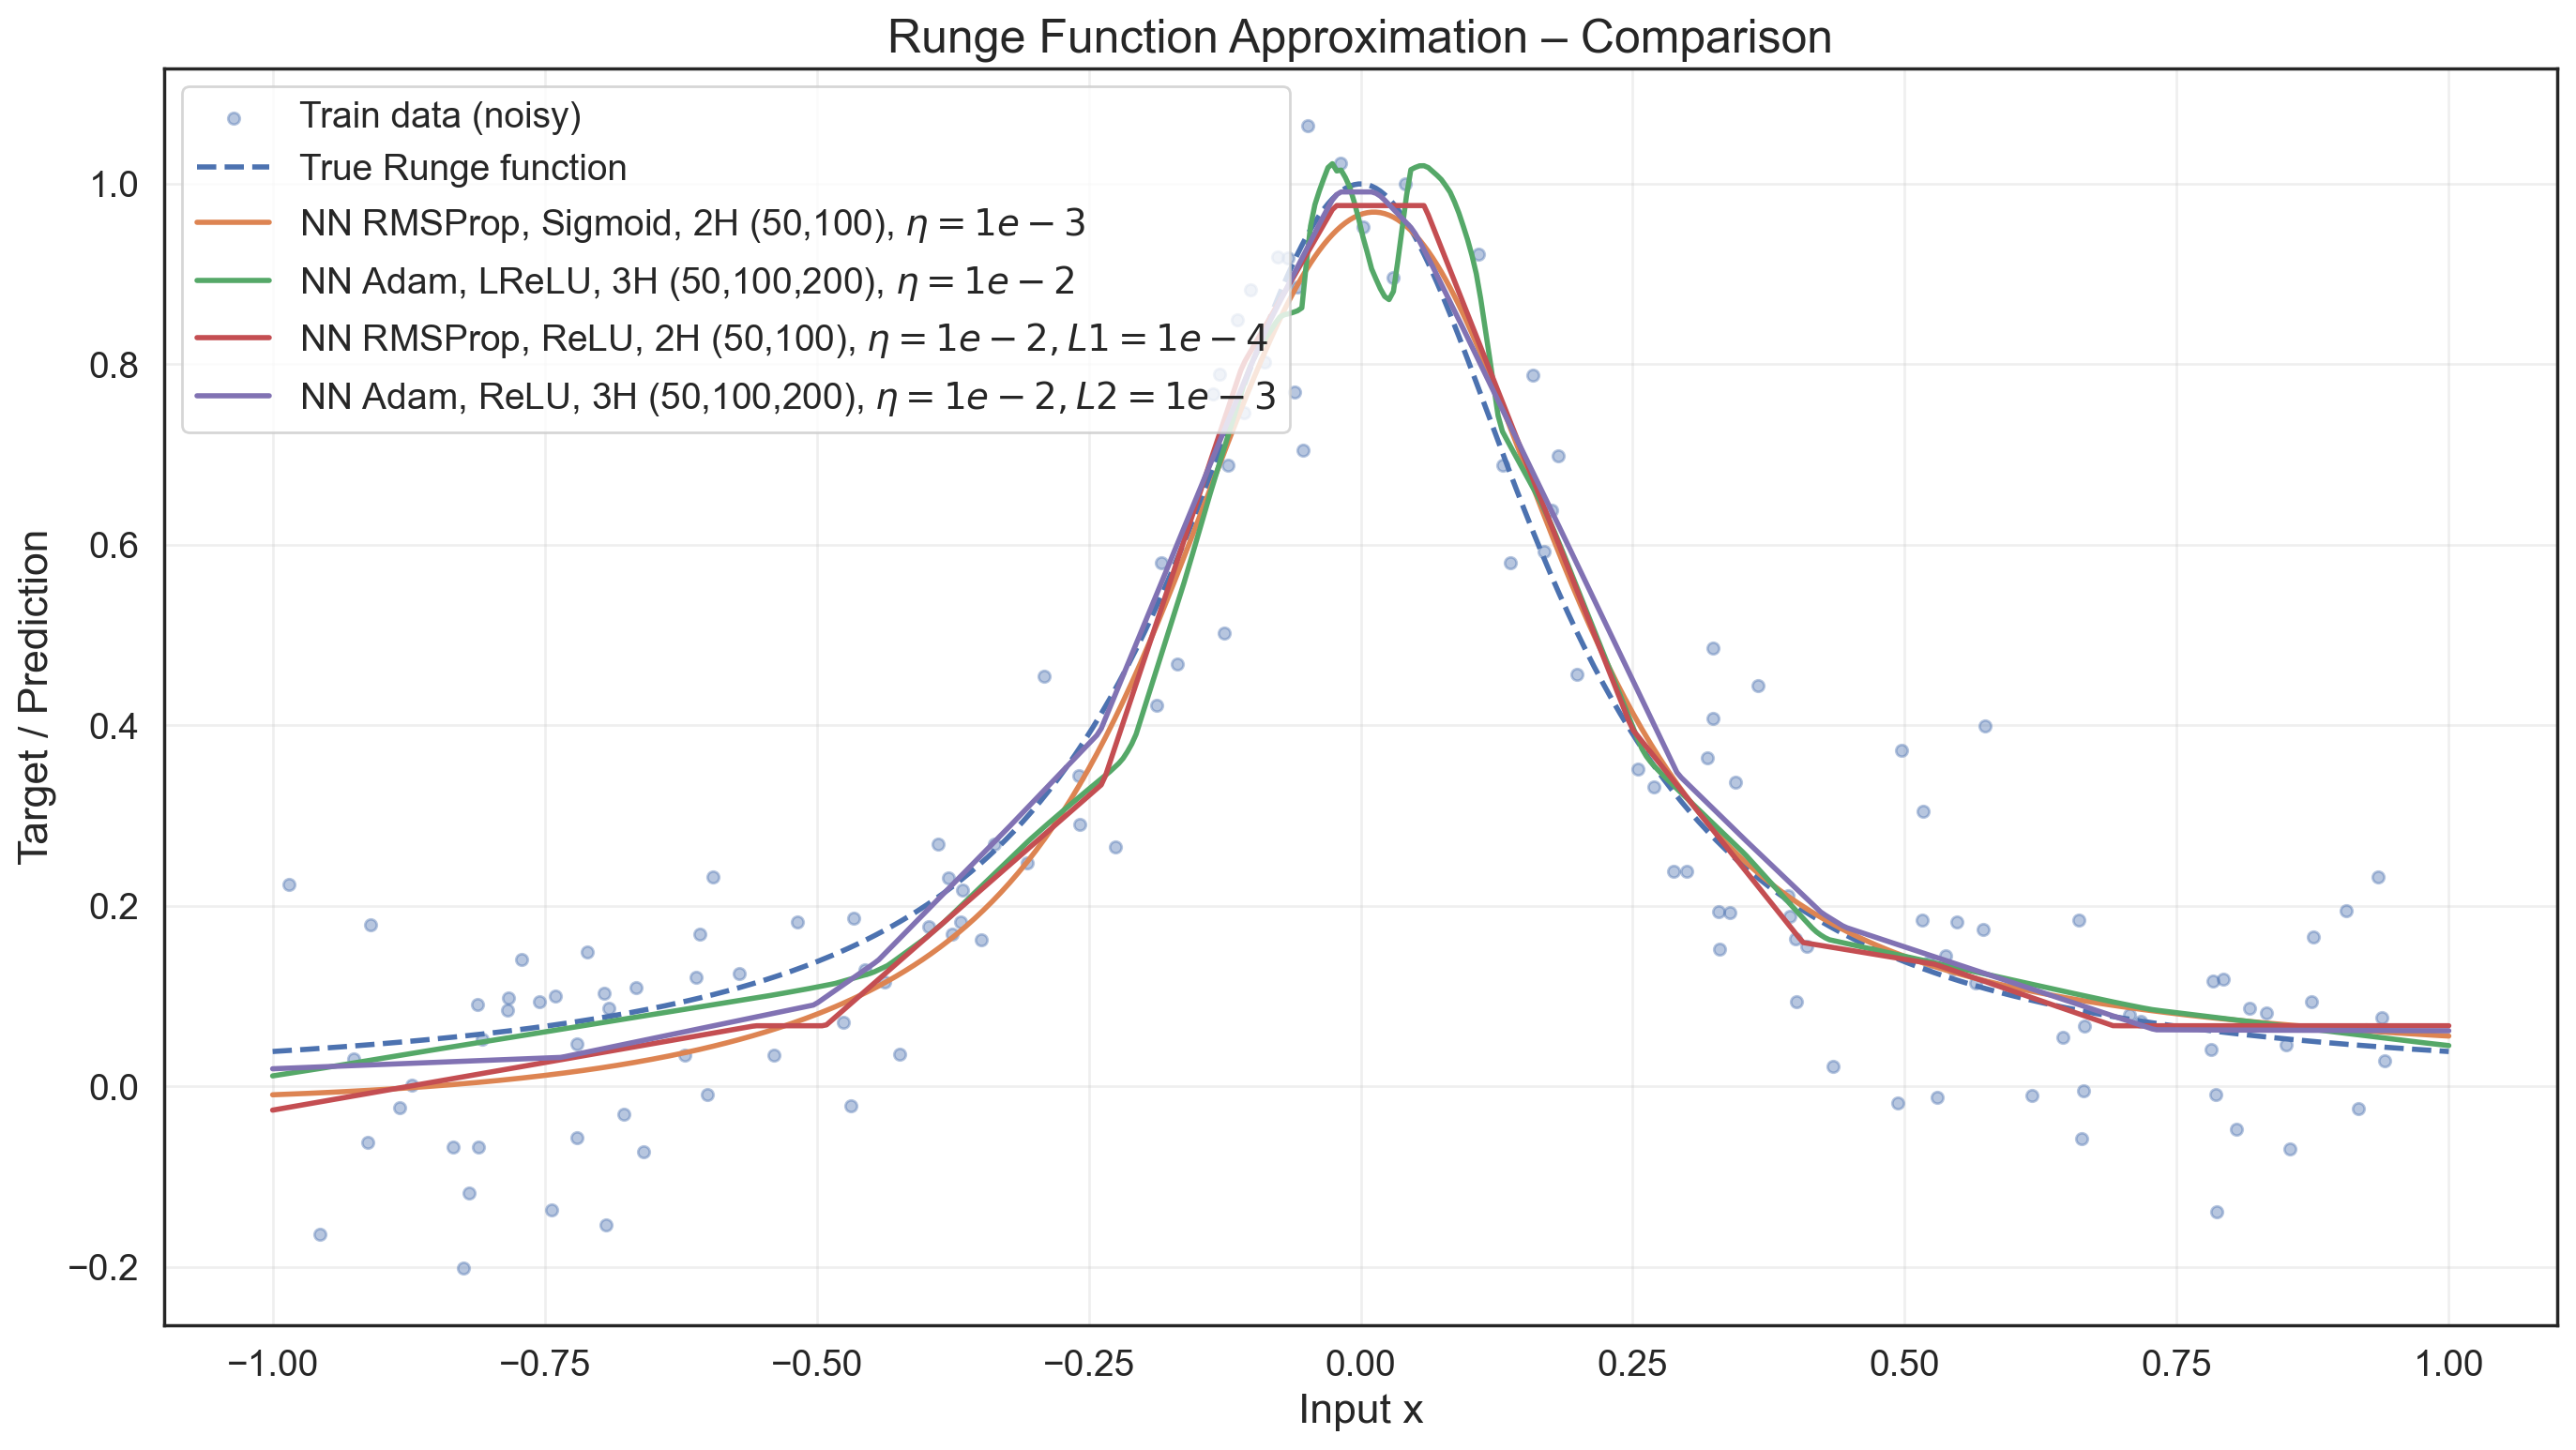

In [ ]:

plt.figure(figsize=(14, 8))

# Noisy train data
plt.scatter(X_train, y_train, s=20, alpha=0.4, label="Train data (noisy)")

# True function
plt.plot(x_plot, y_true, linestyle="--", linewidth=2, label="True Runge function")

# All model predictions
curves = {
    "NN RMSProp, Sigmoid, 2H (50,100), $\eta={1e-3}$": y_pred_b,
    "NN Adam, LReLU, 3H (50,100,200), $\eta=1e-2$":    y_pred_d,
    "NN RMSProp, ReLU, 2H (50,100), $\eta=1e-2, L1=1e-4$":  y_pred_e_L1,
    "NN Adam, ReLU, 3H (50,100,200), $\eta=1e-2, L2=1e-3$": y_pred_e_L2,
}

for label, y_pred in curves.items():
    plt.plot(x_plot, y_pred, linewidth=2, label=label)

plt.xlabel("Input x", fontsize=16)
plt.ylabel("Target / Prediction", fontsize=16)
plt.title("Runge Function Approximation – Comparison", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14, loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
